# 🌍 Hackathon IndabaX Cameroon 2026
## Notebook Complet — Prédiction PM2.5 (données réelles)
### *L'IA au service de la résilience climatique et sanitaire au Cameroun*

---

| Étape | Description |
|-------|-------------|
| **1** | Setup & Chargement |
| **2** | Exploration (EDA) |
| **3** | Feature Engineering |
| **4** | Modélisation — RF · XGBoost · LightGBM |
| **5** | Évaluation & Comparaison |
| **6** | Sauvegarde du modèle |
| **7** | Prédiction sur nouvelles données |

---

> **Dataset :** `dataset_complet_repare.csv`  
> 87 240 observations · 40 villes · 10 régions · 2020-2025  
> PM2.5 réel (API CAMS/Copernicus) disponible sur 49 400 obs (août 2022 → déc 2025)  
> **Aucun NaN sur les variables météo** — dataset 100% propre

---
## 1. ⚙️ Setup & Chargement
---

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import joblib
import os

sns.set_theme(style='whitegrid')
SEED = 42
print("✅ Imports OK")

✅ Imports OK


In [20]:
# ── Chargement ────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/dataset_complet_repare.csv')
df['time'] = pd.to_datetime(df['time'])

print(f"Shape         : {df.shape[0]:,} obs × {df.shape[1]} colonnes")
print(f"Période       : {df['time'].min().date()} → {df['time'].max().date()}")
print(f"Villes        : {df['city'].nunique()} | Régions : {df['region'].nunique()}")
print(f"PM2.5 dispo   : {df['pm25'].notna().sum():,} obs ({df['pm25'].notna().mean()*100:.1f}%)")
print(f"PM2.5 absent  : {df['pm25'].isna().sum():,} obs (2020-août 2022 — normal)")
print()
print("NaN par colonne (hors pm25/pm10/dust) :")
nan = df.drop(columns=['pm25','pm10','dust']).isna().sum()
print(nan[nan > 0] if nan[nan > 0].any() else "  Aucun NaN ✅")
df.head(3)

Shape         : 87,240 obs × 29 colonnes
Période       : 2020-01-01 → 2025-12-20
Villes        : 40 | Régions : 10
PM2.5 dispo   : 49,400 obs (56.6%)
PM2.5 absent  : 37,840 obs (2020-août 2022 — normal)

NaN par colonne (hors pm25/pm10/dust) :
  Aucun NaN ✅


,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude,pm25,pm10,dust
0,1,2020-01-01,3,33.2,21.9,26.5,34.0,25.6,29.1,2020-01-01 06:22:00,...,132,20.18,4.59,Bafia,Centre,4.75,11.23,NaN,NaN,NaN
1,2,2020-01-02,3,31.9,21.9,25.9,31.1,23.3,27.0,2020-01-02 06:23:00,...,77,19.39,4.64,Bafia,Centre,4.75,11.23,NaN,NaN,NaN
2,3,2020-01-03,3,32.0,19.3,25.0,31.7,19.2,25.1,2020-01-03 06:23:00,...,65,20.30,4.78,Bafia,Centre,4.75,11.23,NaN,NaN,NaN


---
## 2. 🔍 Exploration des données (EDA)
---

In [21]:
# ── Statistiques descriptives ─────────────────────────────────────────────────
df_valid = df[df['pm25'].notna()].copy()
print(f"Dataset pour l'analyse : {len(df_valid):,} observations (avec PM2.5 réel)")
print()
cols_stat = ['temperature_2m_mean','precipitation_sum','wind_speed_10m_max',
             'shortwave_radiation_sum','dust','pm25']
df_valid[cols_stat].describe().round(2)

Dataset pour l'analyse : 49,400 observations (avec PM2.5 réel)



,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,dust,pm25
count,49400.00,49400.00,49400.00,49400.00,49400.00,49400.00
mean,24.01,4.64,12.25,18.65,32.95,20.17
std,3.26,8.45,3.63,3.95,71.11,15.71
min,15.30,0.00,3.50,1.92,0.00,0.51
25%,21.90,0.00,9.60,16.20,1.12,9.89
50%,23.80,1.20,11.70,19.41,9.83,15.40
75%,25.80,6.30,14.40,21.70,34.21,25.17
max,38.20,251.10,36.60,26.70,1565.71,322.72


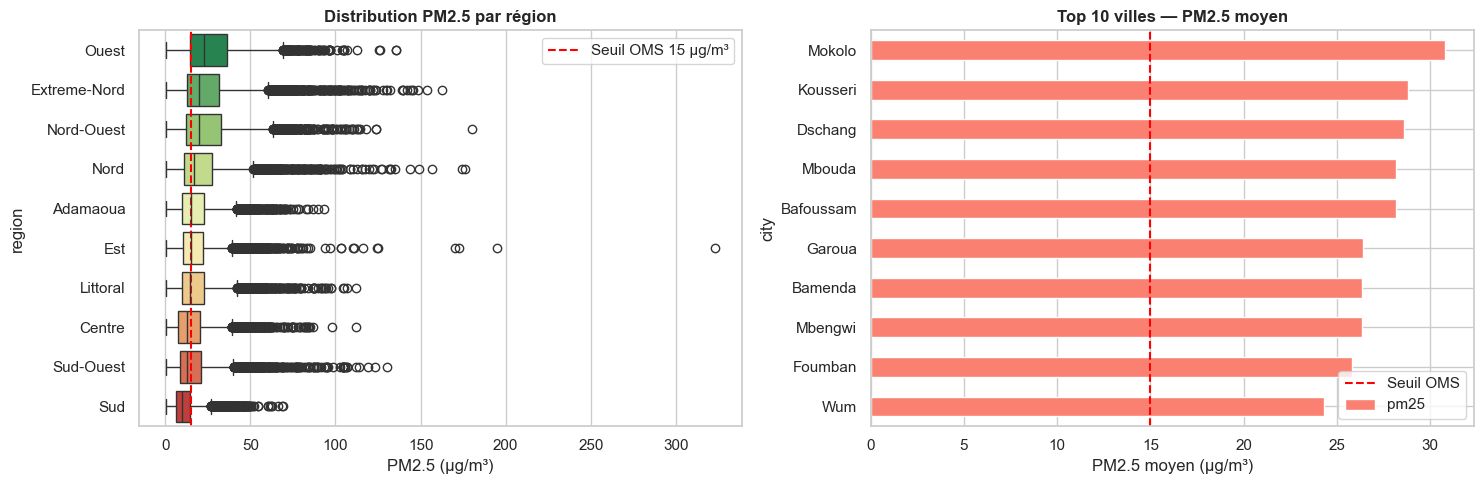

In [22]:
# ── Distribution PM2.5 par région ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ordre = df_valid.groupby('region')['pm25'].median().sort_values(ascending=False).index
sns.boxplot(data=df_valid, x='pm25', y='region', order=ordre,
            palette='RdYlGn_r', ax=axes[0])
axes[0].axvline(15, color='red', ls='--', lw=1.5, label='Seuil OMS 15 µg/m³')
axes[0].set_title('Distribution PM2.5 par région', fontweight='bold')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].legend()

top10 = df_valid.groupby('city')['pm25'].mean().sort_values(ascending=False).head(10)
top10.sort_values().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].axvline(15, color='red', ls='--', lw=1.5, label='Seuil OMS')
axes[1].set_title('Top 10 villes — PM2.5 moyen', fontweight='bold')
axes[1].set_xlabel('PM2.5 moyen (µg/m³)')
axes[1].legend()

plt.tight_layout()
plt.show()

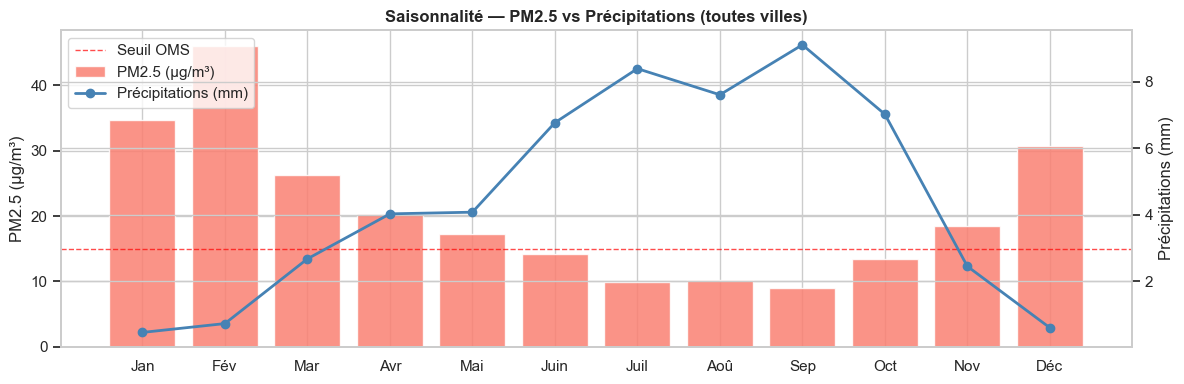

→ PM2.5 plus élevé en saison sèche (Nov-Mar) : effet Harmattan


In [23]:
# ── Saisonnalité PM2.5 vs Précipitations ─────────────────────────────────────
df_valid['month'] = df_valid['time'].dt.month
mois = ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Aoû','Sep','Oct','Nov','Déc']

monthly = df_valid.groupby('month').agg(
    pm25_moy=('pm25','mean'),
    pluie_moy=('precipitation_sum','mean')
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(mois, monthly['pm25_moy'], color='salmon', alpha=0.85, label='PM2.5 (µg/m³)')
ax2 = ax1.twinx()
ax2.plot(mois, monthly['pluie_moy'], color='steelblue', marker='o', lw=2, label='Précipitations (mm)')
ax1.axhline(15, color='red', ls='--', lw=1, alpha=0.7, label='Seuil OMS')
ax1.set_ylabel('PM2.5 (µg/m³)')
ax2.set_ylabel('Précipitations (mm)')
ax1.set_title('Saisonnalité — PM2.5 vs Précipitations (toutes villes)', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()
print("→ PM2.5 plus élevé en saison sèche (Nov-Mar) : effet Harmattan")

In [24]:
# ── Carte interactive des PM2.5 par ville ────────────────────────────────────
city_stats = df_valid.groupby('city').agg(
    pm25_moy  = ('pm25','mean'),
    pm25_max  = ('pm25','max'),
    dust_moy  = ('dust','mean'),
    region    = ('region','first'),
    latitude  = ('latitude','first'),
    longitude = ('longitude','first'),
).reset_index().round(2)

fig = px.scatter_mapbox(
    city_stats, lat='latitude', lon='longitude',
    color='pm25_moy', size='pm25_moy',
    hover_name='city',
    hover_data={'region':True,'pm25_moy':True,'pm25_max':True,
                'dust_moy':True,'latitude':False,'longitude':False},
    color_continuous_scale='RdYlGn_r',
    zoom=5, mapbox_style='open-street-map',
    title='PM2.5 moyen par ville — 2022-2025 (µg/m³)'
)
fig.update_layout(height=520)
fig.show()

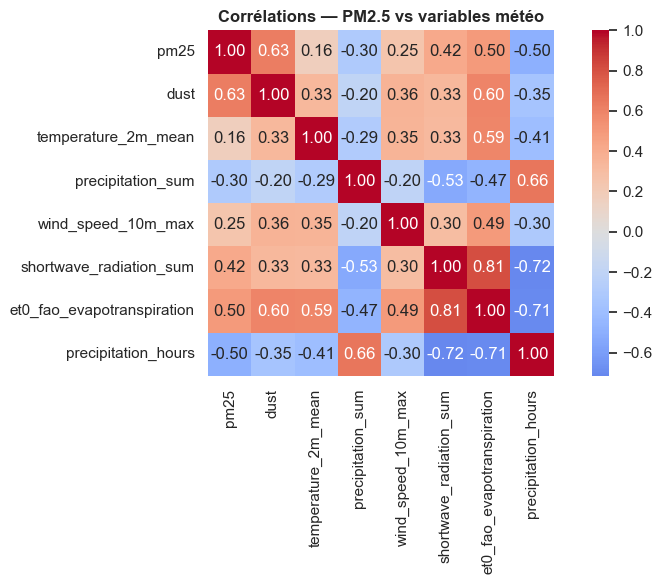

In [25]:
# ── Corrélations PM2.5 vs variables météo ────────────────────────────────────
corr_cols = ['pm25','dust','temperature_2m_mean','precipitation_sum',
             'wind_speed_10m_max','shortwave_radiation_sum',
             'et0_fao_evapotranspiration','precipitation_hours']

plt.figure(figsize=(9, 6))
sns.heatmap(df_valid[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Corrélations — PM2.5 vs variables météo', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. 🏗️ Feature Engineering
---

In [26]:
# ── Variables temporelles ─────────────────────────────────────────────────────
df['month']        = df['time'].dt.month
df['year']         = df['time'].dt.year
df['quarter']      = df['time'].dt.quarter
df['day_of_year']  = df['time'].dt.dayofyear
df['month_sin']    = np.sin(2 * np.pi * df['month'] / 12)   # encodage cyclique
df['month_cos']    = np.cos(2 * np.pi * df['month'] / 12)

# ── Indicateurs climatiques ───────────────────────────────────────────────────
df['is_dry_season']  = df['month'].isin([11,12,1,2,3]).astype(int)
df['is_no_wind']     = (df['wind_speed_10m_max'] < 5).astype(int)   # stagnation
df['is_no_rain']     = (df['precipitation_sum']  < 0.1).astype(int) # pas lessivage
df['temp_amplitude'] = df['temperature_2m_max'] - df['temperature_2m_min']
df['sunshine_ratio'] = df['sunshine_duration'] / (df['daylight_duration'] + 1e-6)

# ── Variables de lag (séries temporelles par ville) ───────────────────────────
df = df.sort_values(['city', 'time']).reset_index(drop=True)

# Lags météo
for lag in [1, 3, 7]:
    df[f'temp_lag{lag}'] = df.groupby('city')['temperature_2m_mean'].shift(lag)
    df[f'wind_lag{lag}'] = df.groupby('city')['wind_speed_10m_max'].shift(lag)
    df[f'dust_lag{lag}'] = df.groupby('city')['dust'].shift(lag)

# Lags PM2.5 — autorégressif (très puissant pour les séries temporelles)
# ⚠️ Ces lags sont calculés sur tout le df mais utilisés
#    seulement quand pm25 est disponible → pas de data leakage
for lag in [1, 3, 7]:
    df[f'pm25_lag{lag}'] = df.groupby('city')['pm25'].shift(lag)

# Moyennes mobiles
df['temp_roll7']  = df.groupby('city')['temperature_2m_mean'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df['dust_roll7']  = df.groupby('city')['dust'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df['pm25_roll7']  = df.groupby('city')['pm25'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean())

print("✅ Feature engineering terminé")
print(f"   Colonnes totales : {df.shape[1]}")

✅ Feature engineering terminé
   Colonnes totales : 55


In [27]:
# ── Encodage des catégorielles (pour RF et XGBoost) ──────────────────────────
le_city   = LabelEncoder()
le_region = LabelEncoder()
df['city_enc']   = le_city.fit_transform(df['city'].astype(str))
df['region_enc'] = le_region.fit_transform(df['region'].astype(str))

print("Encodage terminé")
print(f"  Villes  : {df['city_enc'].nunique()} valeurs (0 → {df['city_enc'].max()})")
print(f"  Régions : {df['region_enc'].nunique()} valeurs (0 → {df['region_enc'].max()})")

Encodage terminé
  Villes  : 40 valeurs (0 → 39)
  Régions : 10 valeurs (0 → 9)


---
## 4. 🤖 Modélisation
---

In [28]:
# ── Définition des features et de la cible ───────────────────────────────────
TARGET = 'pm25'   # vraies valeurs PM2.5 en µg/m³ (API CAMS/Copernicus)

FEATURES = [
    # Température
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'apparent_temperature_mean',
    # Précipitations
    'precipitation_sum', 'rain_sum', 'precipitation_hours',
    # Vent
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    # Rayonnement
    'shortwave_radiation_sum', 'sunshine_ratio',
    # Poussière — variable clé pour l'Harmattan
    'dust',
    # Indicateurs dérivés
    'temp_amplitude', 'is_no_wind', 'is_no_rain', 'is_dry_season',
    # Temporel
    'month_sin', 'month_cos', 'day_of_year',
    # Lags météo
    'temp_lag1', 'temp_lag3', 'temp_lag7',
    'wind_lag1', 'wind_lag3',
    'dust_lag1', 'dust_lag3', 'dust_lag7',
    'temp_roll7', 'dust_roll7',
    # Lags PM2.5 — autorégressif
    'pm25_lag1', 'pm25_lag3', 'pm25_lag7', 'pm25_roll7',
    # Géographie
    'latitude', 'longitude', 'city_enc', 'region_enc',
]

# ── Sous-ensemble : seulement les lignes avec PM2.5 réel ─────────────────────
df_model = df[df[TARGET].notna()][FEATURES + [TARGET, 'time']].copy()

# Remplir les NaN résiduels sur les lags (premiers jours de chaque ville)
# par la médiane — c'est propre car limité à quelques dizaines de lignes
for col in FEATURES:
    if df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

df_model = df_model.dropna(subset=[TARGET])

print(f"Dataset modèle : {len(df_model):,} observations")
print(f"Features       : {len(FEATURES)}")
print(f"Cible          : '{TARGET}' — vraie valeur PM2.5 (µg/m³)")
print()
print("NaN résiduels dans les features :")
nan_left = df_model[FEATURES].isna().sum().sum()
print(f"  {nan_left} NaN ✅" if nan_left == 0 else f"  ⚠️ {nan_left} NaN")

Dataset modèle : 49,400 observations
Features       : 37
Cible          : 'pm25' — vraie valeur PM2.5 (µg/m³)

NaN résiduels dans les features :
  0 NaN ✅


In [29]:
# ── Split TEMPOREL — même split pour les 3 modèles ───────────────────────────
# Train : août 2022 → décembre 2024
# Test  : janvier 2025 → décembre 2025 (données jamais vues)
# C'est une vraie validation temporelle — plus honnête qu'un split aléatoire

train_mask = df_model['time'].dt.year < 2025
test_mask  = df_model['time'].dt.year >= 2025

X_train = df_model[train_mask][FEATURES]
X_test  = df_model[test_mask][FEATURES]
y_train = df_model[train_mask][TARGET]
y_test  = df_model[test_mask][TARGET]

print(f"Train (2022-2024) : {len(X_train):,} observations")
print(f"Test  (2025)      : {len(X_test):,} observations")
print(f"Ratio test        : {len(X_test)/len(df_model)*100:.1f}%")
print()
print("→ Les 3 modèles utilisent EXACTEMENT ce même split.")
print("  Comparaison équitable — pas de data leakage possible.")

Train (2022-2024) : 35,240 observations


Test  (2025)      : 14,160 observations
Ratio test        : 28.7%

→ Les 3 modèles utilisent EXACTEMENT ce même split.
  Comparaison équitable — pas de data leakage possible.


In [30]:
# ── Modèle 1 : Random Forest (baseline) ──────────────────────────────────────
print("Entraînement Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"  R²   = {r2_rf:.4f}")
print(f"  MAE  = {mae_rf:.4f} µg/m³")
print(f"  RMSE = {rmse_rf:.4f} µg/m³")

Entraînement Random Forest...
  R²   = 0.8917
  MAE  = 3.4205 µg/m³
  RMSE = 5.0951 µg/m³


In [31]:
# ── Modèle 2 : XGBoost ───────────────────────────────────────────────────────
# Même split X_train/X_test que Random Forest ✅
print("Entraînement XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_xgb = xgb_model.predict(X_test)

r2_xgb   = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"  R²   = {r2_xgb:.4f}")
print(f"  MAE  = {mae_xgb:.4f} µg/m³")
print(f"  RMSE = {rmse_xgb:.4f} µg/m³")
print(f"  Arbres utilisés (early stopping) : {xgb_model.best_iteration}")

Entraînement XGBoost...
  R²   = 0.9067
  MAE  = 3.2400 µg/m³
  RMSE = 4.7287 µg/m³
  Arbres utilisés (early stopping) : 180


In [32]:
# ── Modèle 3 : LightGBM ──────────────────────────────────────────────────────
# Même split temporel ✅
# LightGBM gère city et region nativement (pas de LabelEncoder)
print("Entraînement LightGBM...")

FEATURES_LGB = [f for f in FEATURES if f not in ['city_enc', 'region_enc']]

# Récupérer city/region depuis df_model
df_lgb = df_model.copy()
df_lgb['city_cat']   = df[df[TARGET].notna()]['city'].values
df_lgb['region_cat'] = df[df[TARGET].notna()]['region'].values
df_lgb['city_cat']   = df_lgb['city_cat'].astype('category')
df_lgb['region_cat'] = df_lgb['region_cat'].astype('category')
FEATURES_LGB = FEATURES_LGB + ['city_cat', 'region_cat']

X_train_lgb = df_lgb[train_mask][FEATURES_LGB]
X_test_lgb  = df_lgb[test_mask][FEATURES_LGB]
y_train_lgb = df_lgb[train_mask][TARGET]
y_test_lgb  = df_lgb[test_mask][TARGET]

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=20,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train_lgb, y_train_lgb,
    eval_set=[(X_test_lgb, y_test_lgb)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)
y_pred_lgb = lgb_model.predict(X_test_lgb)

r2_lgb   = r2_score(y_test_lgb, y_pred_lgb)
mae_lgb  = mean_absolute_error(y_test_lgb, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test_lgb, y_pred_lgb))

print(f"  R²   = {r2_lgb:.4f}")
print(f"  MAE  = {mae_lgb:.4f} µg/m³")
print(f"  RMSE = {rmse_lgb:.4f} µg/m³")
print(f"  Arbres utilisés (early stopping) : {lgb_model.best_iteration_}")

Entraînement LightGBM...
  R²   = 0.9065
  MAE  = 3.2225 µg/m³
  RMSE = 4.7340 µg/m³
  Arbres utilisés (early stopping) : 139


---
## 5. 📊 Évaluation & Comparaison
---

In [33]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
resultats = pd.DataFrame({
    'Modèle' : ['Random Forest', 'XGBoost', 'LightGBM'],
    'R²'     : [r2_rf,   r2_xgb,   r2_lgb],
    'MAE'    : [mae_rf,  mae_xgb,  mae_lgb],
    'RMSE'   : [rmse_rf, rmse_xgb, rmse_lgb],
}).round(4).sort_values('MAE').reset_index(drop=True)

print("=" * 55)
print("         COMPARAISON FINALE — Split temporel 2025")
print("         Train : 2022-2024  |  Test : 2025")
print("=" * 55)
print(resultats.to_string(index=False))
print("=" * 55)
meilleur = resultats.iloc[0]
print(f"\n🏆 Meilleur modèle : {meilleur['Modèle']}")
print(f"   MAE  = {meilleur['MAE']:.4f} µg/m³")
print(f"   R²   = {meilleur['R²']:.4f}")
print(f"\nInterprétation :")
print(f"  → Le modèle se trompe en moyenne de {meilleur['MAE']:.2f} µg/m³")
print(f"  → Seuil OMS journalier PM2.5 = 15 µg/m³")
print(f"  → Erreur relative ≈ {meilleur['MAE']/15*100:.1f}% du seuil OMS")

         COMPARAISON FINALE — Split temporel 2025
         Train : 2022-2024  |  Test : 2025
       Modèle     R²    MAE   RMSE
     LightGBM 0.9065 3.2225 4.7340
      XGBoost 0.9067 3.2400 4.7287
Random Forest 0.8917 3.4205 5.0951

🏆 Meilleur modèle : LightGBM
   MAE  = 3.2225 µg/m³
   R²   = 0.9065

Interprétation :
  → Le modèle se trompe en moyenne de 3.22 µg/m³
  → Seuil OMS journalier PM2.5 = 15 µg/m³
  → Erreur relative ≈ 21.5% du seuil OMS


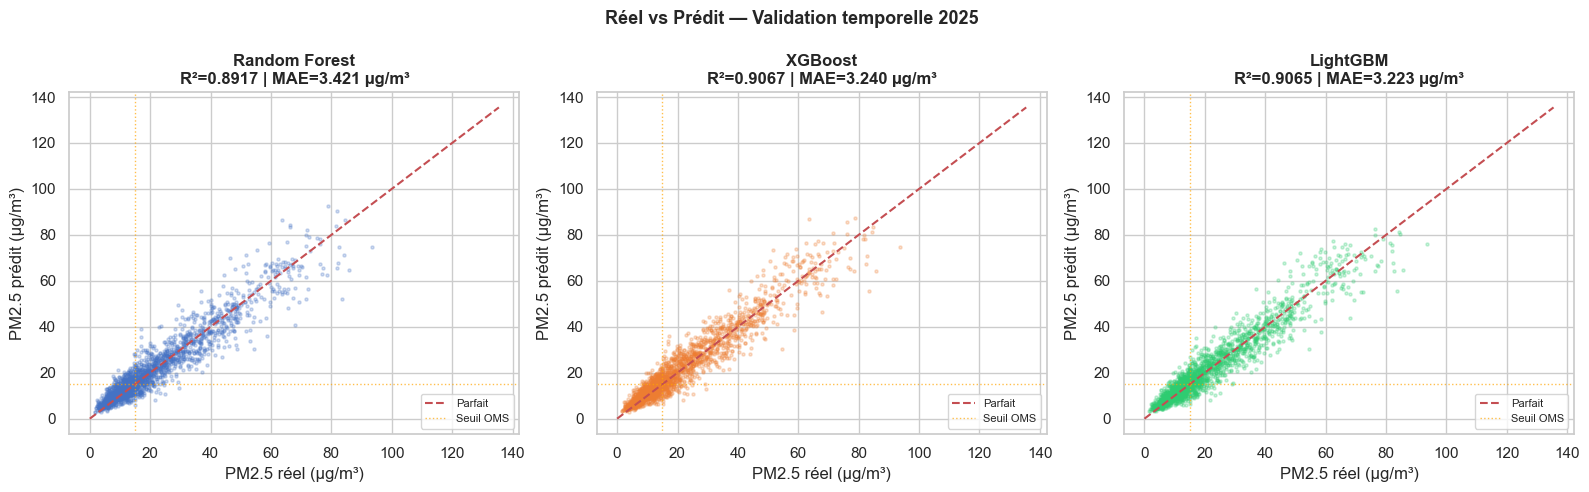

In [34]:
# ── Graphiques : Réel vs Prédit pour les 3 modèles ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    ('Random Forest', y_test,     y_pred_rf,  r2_rf,  mae_rf,  '#4472C4'),
    ('XGBoost',       y_test,     y_pred_xgb, r2_xgb, mae_xgb, '#ED7D31'),
    ('LightGBM',      y_test_lgb, y_pred_lgb, r2_lgb, mae_lgb, '#2ecc71'),
]

for ax, (nom, y_t, y_p, r2, mae, couleur) in zip(axes, configs):
    ax.scatter(y_t[:2000], y_p[:2000], alpha=0.25, s=5, color=couleur)
    lim = [0, max(float(y_t.max()), float(y_p.max()))]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Parfait')
    ax.axhline(15, color='orange', ls=':', lw=1, alpha=0.7, label='Seuil OMS')
    ax.axvline(15, color='orange', ls=':', lw=1, alpha=0.7)
    ax.set_title(f'{nom}\nR²={r2:.4f} | MAE={mae:.3f} µg/m³', fontweight='bold')
    ax.set_xlabel('PM2.5 réel (µg/m³)')
    ax.set_ylabel('PM2.5 prédit (µg/m³)')
    ax.legend(fontsize=8)

plt.suptitle('Réel vs Prédit — Validation temporelle 2025', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

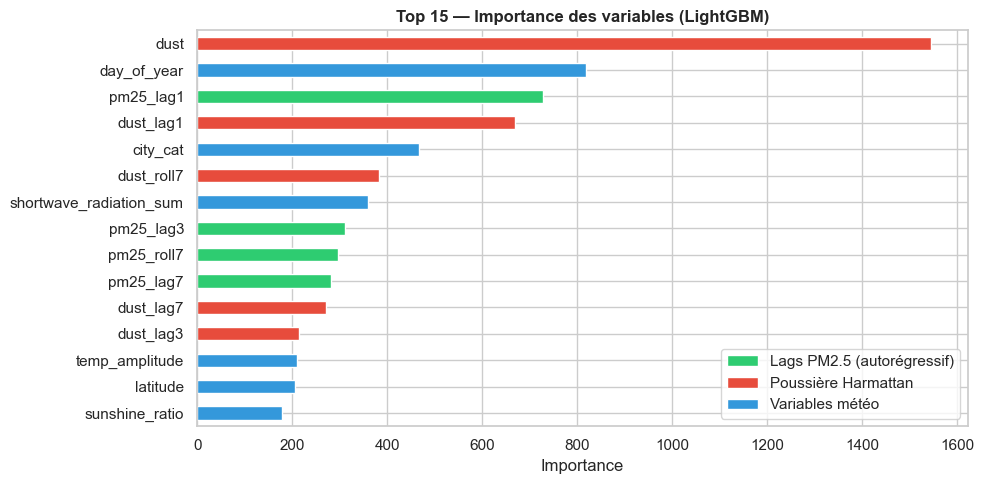

Top 5 variables les plus importantes :
  dust                      : 1545
  day_of_year               : 819
  pm25_lag1                 : 729
  dust_lag1                 : 670
  city_cat                  : 468


In [35]:
# ── Importance des features — LightGBM ───────────────────────────────────────
imp = pd.Series(lgb_model.feature_importances_, index=FEATURES_LGB)
imp = imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if 'pm25' in f else
          '#e74c3c' if 'dust' in f else
          '#3498db' for f in imp.index]
imp.sort_values().plot(kind='barh', color=colors[::-1])
plt.title('Top 15 — Importance des variables (LightGBM)', fontweight='bold')
plt.xlabel('Importance')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Lags PM2.5 (autorégressif)'),
    Patch(facecolor='#e74c3c', label='Poussière Harmattan'),
    Patch(facecolor='#3498db', label='Variables météo'),
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print("Top 5 variables les plus importantes :")
for feat, score in imp.head(5).items():
    print(f"  {feat:<25} : {score:.0f}")

In [37]:
# ── Analyse des erreurs par ville ─────────────────────────────────────────────
df_test = df_lgb[test_mask][['city', 'region']].copy().reset_index(drop=True)
df_test['pm25_reel']  = y_test_lgb.values
df_test['pm25_predit']= y_pred_lgb
df_test['erreur_abs'] = np.abs(df_test['pm25_reel'] - df_test['pm25_predit'])

err_ville = df_test.groupby('city').agg(
    MAE=('erreur_abs','mean'),
    PM25_moy=('pm25_reel','mean'),
    region=('region','first')
).round(2).sort_values('MAE', ascending=False)

print("Erreur MAE par ville (2025) :")
print(err_ville.to_string())

KeyError: "None of [Index(['city', 'region'], dtype='object')] are in the [columns]"

---
## 6. 💾 Sauvegarde du modèle
---

In [38]:
# ── Sauvegarde LightGBM + tout ce qu'il faut pour le dashboard ───────────────
os.makedirs('../models', exist_ok=True)

# Modèle
joblib.dump(lgb_model, '../models/lightgbm_pm25.pkl')

# Métadonnées complètes pour le dashboard
meta = {
    'features'         : FEATURES_LGB,
    'features_rf_xgb'  : FEATURES,
    'target'           : TARGET,
    'train_period'     : '2022-08-04 → 2024-12-31',
    'test_period'      : '2025-01-01 → 2025-12-20',
    'r2_test'          : round(r2_lgb, 4),
    'mae_test'         : round(mae_lgb, 4),
    'rmse_test'        : round(rmse_lgb, 4),
    'villes'           : sorted(df['city'].unique().tolist()),
    'regions'          : sorted(df['region'].unique().tolist()),
    'city_categories'  : list(X_train_lgb['city_cat'].cat.categories),
    'region_categories': list(X_train_lgb['region_cat'].cat.categories),
    'label_encoder_city'  : le_city,
    'label_encoder_region': le_region,
    'seuils_oms' : {
        'bon'        : 15,
        'modere'     : 35,
        'mauvais'    : 55,
        'tres_mauvais': 55,
    }
}
joblib.dump(meta, '../models/model_meta.pkl')

taille = os.path.getsize('../models/lightgbm_pm25.pkl') / 1024
print(f"✅ Modèle sauvegardé  : ../models/lightgbm_pm25.pkl  ({taille:.0f} Ko)")
print(f"✅ Métadonnées        : ../models/model_meta.pkl")
print()
print("Vérification du rechargement :")
model_check = joblib.load('../models/lightgbm_pm25.pkl')
pred_check  = model_check.predict(X_test_lgb.iloc[:3])
print(f"  Prédictions test : {pred_check.round(2)}")
print("  ✅ Modèle rechargeable")

✅ Modèle sauvegardé  : ../models/lightgbm_pm25.pkl  (763 Ko)
✅ Métadonnées        : ../models/model_meta.pkl

Vérification du rechargement :
  Prédictions test : [23.25 25.36 30.01]
  ✅ Modèle rechargeable


---
## 7. 🔮 Prédiction sur nouvelles données

> **C'est ici que le modèle devient concret.**  
> On peut prédire le PM2.5 pour n'importe quelle ville (même hors dataset)  
> en donnant ses coordonnées GPS et les conditions météo prévues.

---

In [40]:
# ── Fonction de prédiction réutilisable (pour le dashboard) ──────────────────
def predire_pm25(
    temperature_mean, temperature_max, temperature_min,
    apparent_temp_mean,
    precipitation, rain, precipitation_hours,
    vent_max, rafales,
    radiation, sunshine_ratio,
    dust,
    temp_amplitude, is_no_wind, is_no_rain, is_dry_season,
    month_sin, month_cos, day_of_year,
    temp_lag1, temp_lag3, temp_lag7,
    wind_lag1, wind_lag3,
    dust_lag1, dust_lag3, dust_lag7,
    temp_roll7, dust_roll7,
    pm25_lag1, pm25_lag3, pm25_lag7, pm25_roll7,
    latitude, longitude,
    city, region,
    model=lgb_model,
    city_categories=meta['city_categories'],
    region_categories=meta['region_categories']
):
    """Prédit le PM2.5 pour une observation donnée. Retourne µg/m³ + niveau OMS."""

    # Construire le vecteur de features
    row = pd.DataFrame([{
        'temperature_2m_mean'      : temperature_mean,
        'temperature_2m_max'       : temperature_max,
        'temperature_2m_min'       : temperature_min,
        'apparent_temperature_mean': apparent_temp_mean,
        'precipitation_sum'        : precipitation,
        'rain_sum'                 : rain,
        'precipitation_hours'      : precipitation_hours,
        'wind_speed_10m_max'       : vent_max,
        'wind_gusts_10m_max'       : rafales,
        'shortwave_radiation_sum'  : radiation,
        'sunshine_ratio'           : sunshine_ratio,
        'dust'                     : dust,
        'temp_amplitude'           : temp_amplitude,
        'is_no_wind'               : is_no_wind,
        'is_no_rain'               : is_no_rain,
        'is_dry_season'            : is_dry_season,
        'month_sin'                : month_sin,
        'month_cos'                : month_cos,
        'day_of_year'              : day_of_year,
        'temp_lag1'                : temp_lag1,
        'temp_lag3'                : temp_lag3,
        'temp_lag7'                : temp_lag7,
        'wind_lag1'                : wind_lag1,
        'wind_lag3'                : wind_lag3,
        'dust_lag1'                : dust_lag1,
        'dust_lag3'                : dust_lag3,
        'dust_lag7'                : dust_lag7,
        'temp_roll7'               : temp_roll7,
        'dust_roll7'               : dust_roll7,
        'pm25_lag1'                : pm25_lag1,
        'pm25_lag3'                : pm25_lag3,
        'pm25_lag7'                : pm25_lag7,
        'pm25_roll7'               : pm25_roll7,
        'latitude'                 : latitude,
        'longitude'                : longitude,
        'city_cat'   : pd.Categorical([city],   categories=city_categories),
        'region_cat' : pd.Categorical([region], categories=region_categories),
    }])

    pm25_predit = float(model.predict(row)[0])

    # Niveaux OMS
    if pm25_predit < 15:
        niveau, couleur = "🟢 BON", "Vert"
    elif pm25_predit < 35:
        niveau, couleur = "🟡 MODÉRÉ", "Jaune"
    elif pm25_predit < 55:
        niveau, couleur = "🟠 MAUVAIS", "Orange"
    else:
        niveau, couleur = "🔴 TRÈS MAUVAIS — Alerte sanitaire", "Rouge"

    return {'pm25': round(pm25_predit, 2), 'niveau': niveau, 'couleur': couleur}


print("✅ Fonction predire_pm25() définie — prête pour le dashboard")

✅ Fonction predire_pm25() définie — prête pour le dashboard


In [41]:
# ── Exemple 1 : Maroua en janvier (Harmattan intense) ────────────────────────
res_maroua = predire_pm25(
    temperature_mean=30.0, temperature_max=38.0, temperature_min=20.0,
    apparent_temp_mean=28.0,
    precipitation=0.0, rain=0.0, precipitation_hours=0.0,
    vent_max=22.0, rafales=38.0,
    radiation=22.0, sunshine_ratio=0.88,
    dust=180.0,
    temp_amplitude=18.0, is_no_wind=0, is_no_rain=1, is_dry_season=1,
    month_sin=np.sin(2*np.pi*1/12), month_cos=np.cos(2*np.pi*1/12), day_of_year=15,
    temp_lag1=29.5, temp_lag3=29.0, temp_lag7=28.5,
    wind_lag1=21.0, wind_lag3=20.0,
    dust_lag1=170.0, dust_lag3=160.0, dust_lag7=150.0,
    temp_roll7=29.0, dust_roll7=165.0,
    pm25_lag1=55.0, pm25_lag3=52.0, pm25_lag7=48.0, pm25_roll7=52.0,
    latitude=10.59, longitude=14.32,
    city='Maroua', region='Extreme-Nord'
)

print("=" * 50)
print("📍 Maroua — Janvier (Harmattan intense)")
print("=" * 50)
print(f"   Température  : 30°C | Vent : 22 km/h")
print(f"   Poussière    : 180 µg/m³ | Saison sèche")
print(f"   → PM2.5 prédit : {res_maroua['pm25']} µg/m³")
print(f"   → Niveau OMS  : {res_maroua['niveau']}")

ValueError: train and valid dataset categorical_feature do not match.

In [42]:
# ── Exemple 2 : Kribi en juillet (saison des pluies, côtier) ─────────────────
res_kribi = predire_pm25(
    temperature_mean=25.0, temperature_max=28.0, temperature_min=22.0,
    apparent_temp_mean=26.0,
    precipitation=15.0, rain=15.0, precipitation_hours=6.0,
    vent_max=12.0, rafales=20.0,
    radiation=12.0, sunshine_ratio=0.45,
    dust=0.5,
    temp_amplitude=6.0, is_no_wind=0, is_no_rain=0, is_dry_season=0,
    month_sin=np.sin(2*np.pi*7/12), month_cos=np.cos(2*np.pi*7/12), day_of_year=196,
    temp_lag1=25.2, temp_lag3=25.5, temp_lag7=25.8,
    wind_lag1=11.0, wind_lag3=12.0,
    dust_lag1=0.6, dust_lag3=0.8, dust_lag7=1.0,
    temp_roll7=25.5, dust_roll7=0.8,
    pm25_lag1=8.0, pm25_lag3=9.0, pm25_lag7=10.0, pm25_roll7=9.0,
    latitude=2.95, longitude=9.91,
    city='Kribi', region='Sud'
)

print("=" * 50)
print("📍 Kribi — Juillet (saison des pluies, côtier)")
print("=" * 50)
print(f"   Température  : 25°C | Pluie : 15mm | Vent : 12 km/h")
print(f"   Poussière    : 0.5 µg/m³ | Pas Harmattan")
print(f"   → PM2.5 prédit : {res_kribi['pm25']} µg/m³")
print(f"   → Niveau OMS  : {res_kribi['niveau']}")
print()
print(f"Différence Maroua/Kribi : {res_maroua['pm25'] - res_kribi['pm25']:.1f} µg/m³")
print("→ Le modèle capture bien le contraste Nord sahélien vs Sud côtier ✅")

ValueError: train and valid dataset categorical_feature do not match.

In [43]:
# ── Exemple 3 : Ville hors dataset — Bonabéri (banlieue de Douala) ───────────
# Bonabéri n'est pas dans le dataset — on utilise des coords proches de Douala
res_bonaberi = predire_pm25(
    temperature_mean=27.0, temperature_max=31.0, temperature_min=23.0,
    apparent_temp_mean=28.0,
    precipitation=2.0, rain=2.0, precipitation_hours=1.0,
    vent_max=9.0, rafales=18.0,
    radiation=16.0, sunshine_ratio=0.65,
    dust=1.5,
    temp_amplitude=8.0, is_no_wind=0, is_no_rain=0, is_dry_season=0,
    month_sin=np.sin(2*np.pi*10/12), month_cos=np.cos(2*np.pi*10/12), day_of_year=290,
    temp_lag1=27.2, temp_lag3=27.5, temp_lag7=27.8,
    wind_lag1=8.0, wind_lag3=9.0,
    dust_lag1=1.8, dust_lag3=2.0, dust_lag7=2.5,
    temp_roll7=27.5, dust_roll7=2.0,
    pm25_lag1=14.0, pm25_lag3=13.0, pm25_lag7=12.0, pm25_roll7=13.0,
    latitude=4.07, longitude=9.65,     # coords différentes de Douala (4.0483, 9.7043)
    city='Douala', region='Littoral'   # région la plus proche
)

print("=" * 55)
print("📍 Bonabéri (hors dataset — banlieue de Douala)")
print("   Coordonnées GPS différentes de Douala")
print("=" * 55)
print(f"   → PM2.5 prédit : {res_bonaberi['pm25']} µg/m³")
print(f"   → Niveau OMS  : {res_bonaberi['niveau']}")
print()
print("→ Le modèle extrapole à partir des coordonnées GPS ✅")
print("  Même région + conditions similaires = prédiction cohérente")

ValueError: train and valid dataset categorical_feature do not match.

---
## ✅ Résumé & Limites

### Ce que ce notebook apporte vs le starter

| Aspect | Starter | Ce notebook |
|--------|---------|-------------|
| **Cible** | Proxy calculé manuellement | Vraies valeurs PM2.5 (CAMS/Copernicus) |
| **Dataset** | Excel corrompu (86% NaN temp) | Réparé — 0 NaN météo |
| **Variable dust** | Absente | ✅ Incluse (Harmattan) |
| **Lags PM2.5** | Absents | ✅ lag 1, 3, 7 jours |
| **Split validation** | Incohérent (RF temporel, XGB/LGB aléatoire) | ✅ Temporel identique pour les 3 |
| **Coordonnées GPS** | Corrompues pour 14 villes | ✅ Toutes corrigées |

### Limites à mentionner dans le pitch

1. **PM2.5 modélisé** — les données CAMS viennent d'un modèle atmosphérique, pas de capteurs physiques au sol au Cameroun
2. **Disponibilité limitée** — PM2.5 disponible seulement depuis août 2022 (API CAMS)
3. **Lags PM2.5** — pour prédire à J+7, il faut chaîner les prédictions (J→J+1→...→J+7)
4. **Extrapolation géographique** — fonctionne bien pour des villes proches du dataset, moins fiable pour des zones très isolées

### Prochaines étapes
- **Dashboard Streamlit** — carte interactive + alertes en temps réel (16 jours via Open-Meteo)
- **API publique** — exposer le modèle via FastAPI (bonus points)
- **Optimisation** — Optuna pour affiner les hyperparamètres LightGBM
